In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU: []


In [3]:
import tensorflow as tf

# Dataset paths
train_dir = r"C:\Projects\Ai-powered-classroom-engagement-system\dataset\MRL eye\train"
val_dir   = r"C:\Projects\Ai-powered-classroom-engagement-system\dataset\MRL eye\val"
test_dir  = r"C:\Projects\Ai-powered-classroom-engagement-system\dataset\MRL eye\test"

# Image settings
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

print("Dataset paths set successfully!")
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Dataset paths set successfully!
Image size: (64, 64)
Batch size: 32


In [4]:
train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

print("Training dataset loaded!")
print("Classes:", train_data.class_names)

Found 50937 files belonging to 2 classes.
Training dataset loaded!
Classes: ['awake', 'sleepy']


In [5]:
val_data = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Validation dataset loaded!")
print("Classes:", val_data.class_names)

Found 16980 files belonging to 2 classes.
Validation dataset loaded!
Classes: ['awake', 'sleepy']


In [6]:
test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Test dataset loaded!")
print("Classes:", test_data.class_names)

Found 16981 files belonging to 2 classes.
Test dataset loaded!
Classes: ['awake', 'sleepy']


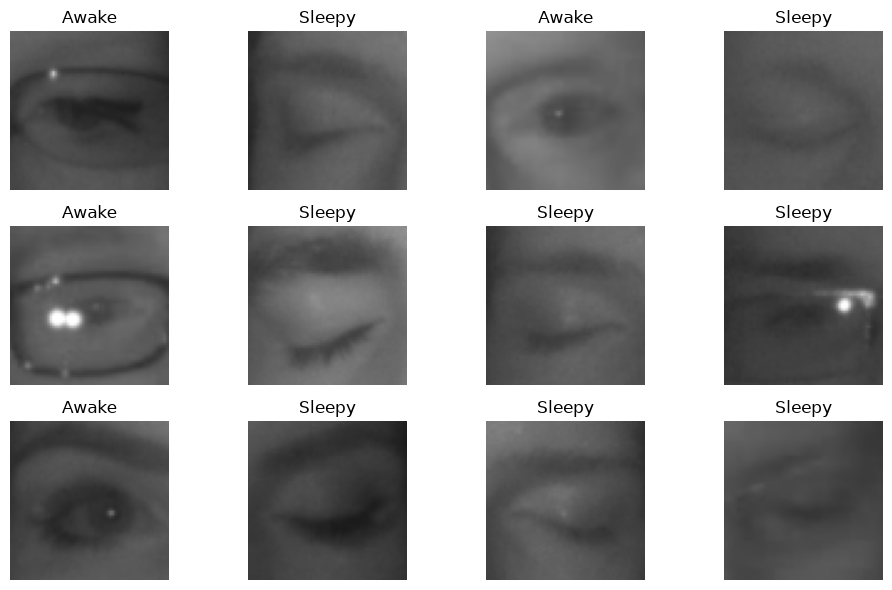

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for images, labels in train_data.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title("Awake" if labels[i].numpy() == 0 else "Sleepy")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(
    lambda x, y: (normalization_layer(x), y)
)

val_data = val_data.map(
    lambda x, y: (normalization_layer(x), y)
)

test_data = test_data.map(
    lambda x, y: (normalization_layer(x), y)
)

print("Normalization completed!")

Normalization completed!


In [11]:
for images, labels in train_data.take(1):
    print("Image shape:", images.shape)
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())
    print("Label shape:", labels.shape)

Image shape: (32, 64, 64, 3)
Minimum pixel value: 0.0022058825
Maximum pixel value: 1.0
Label shape: (32, 1)


In [12]:
model = tf.keras.Sequential([
    
    # Input
    tf.keras.layers.Input(shape=(64, 64, 3)),

    # CNN Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # CNN Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # CNN Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convert feature maps to a vector
    tf.keras.layers.Flatten(),

    # Fully connected layer
    tf.keras.layers.Dense(128, activation='relu'),

    # Prevent overfitting
    tf.keras.layers.Dropout(0.5),

    # Output: Awake / Sleepy
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [14]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10


c:\Projects\Ai-powered-classroom-engagement-system\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1592/1592 ━━━━━━━━━━━━━━━━━━━━ 270s 169ms/step - accuracy: 0.9270 - loss: 0.1914 - val_accuracy: 0.9710 - val_loss: 0.0840
Epoch 2/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 61s 38ms/step - accuracy: 0.9704 - loss: 0.0847 - val_accuracy: 0.9802 - val_loss: 0.0593
Epoch 3/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 99s 62ms/step - accuracy: 0.9774 - loss: 0.0651 - val_accuracy: 0.9810 - val_loss: 0.0537
Epoch 4/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 238s 150ms/step - accuracy: 0.9799 - loss: 0.0563 - val_accuracy: 0.9832 - val_loss: 0.0496
Epoch 5/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 290s 182ms/step - accuracy: 0.9824 - loss: 0.0498 - val_accuracy: 0.9837 - val_loss: 0.0468
Epoch 6/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 295s 185ms/step - accuracy: 0.9829 - loss: 0.0478 - val_accuracy: 0.9856 - val_loss: 0.0415
Epoch 7/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 183s 115ms/step - accuracy: 0.9850 - loss: 0.0420 - val_accuracy: 0.9870 - val_loss: 0.0385
Epoch 8/10
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 242s 152ms/step - accuracy: 0.9867 

In [15]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

531/531 ━━━━━━━━━━━━━━━━━━━━ 47s 87ms/step - accuracy: 0.9884 - loss: 0.0362
Test Loss: 0.036209385842084885
Test Accuracy: 0.9883987903594971


In [17]:
%pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 1.3 MB/s eta 0:00:06
   ----- ---------------------------------- 1.0/8.2 MB 1.9 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.2 MB 1.3 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.2 MB 1.5 MB/s eta 0:00:05
   -------- ------------------------------- 1.8/8.2 MB 1.4 MB/s eta 0:00:05
   ------------ --------------------------- 2.6/8.2 MB 1.7 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.2 MB 1.6 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.2 MB 1.6 MB/s eta 0:00:04
   -------------- ------------------------- 2.9

In [20]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[8463  128]
 [  69 8321]]


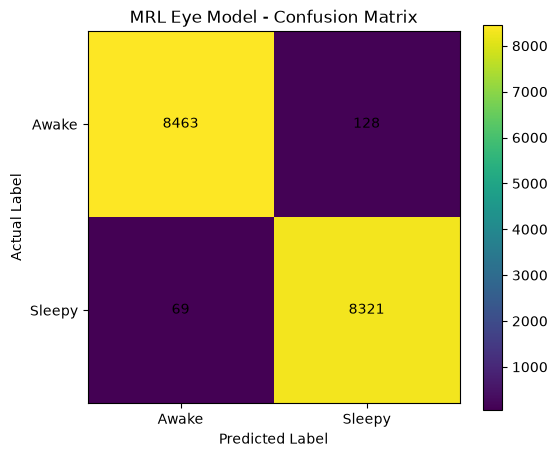

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xticks([0, 1], ['Awake', 'Sleepy'])
plt.yticks([0, 1], ['Awake', 'Sleepy'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('MRL Eye Model - Confusion Matrix')

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

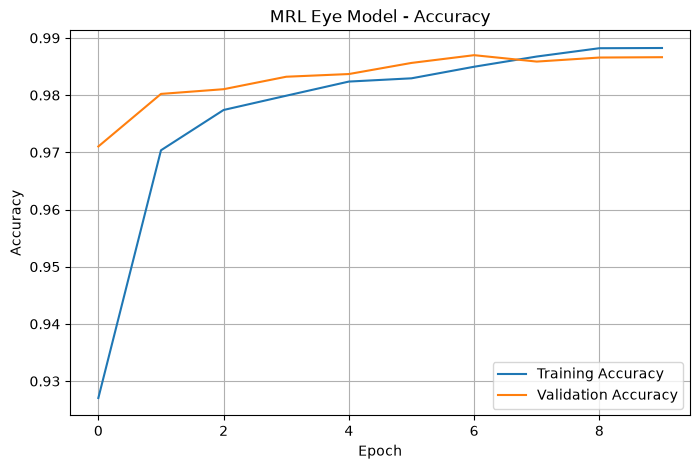

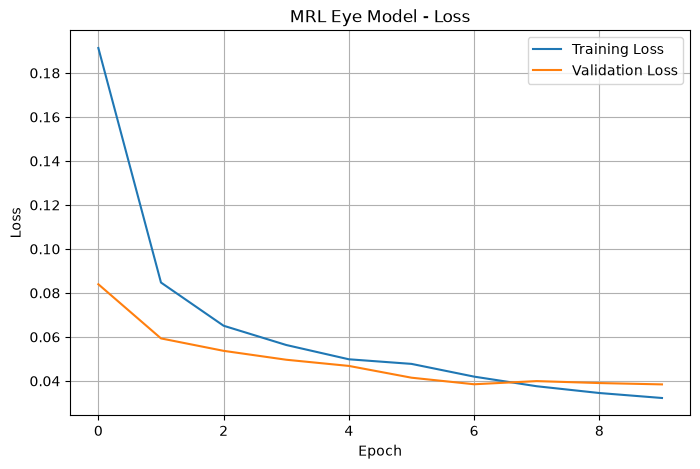

In [23]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MRL Eye Model - Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# Loss graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MRL Eye Model - Loss')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
model_path = r"C:\Projects\Ai-powered-classroom-engagement-system\ai-model\models\mrl_eye_model.keras"

model.save(model_path)

print("Model saved successfully!")
print("Location:", model_path)

Model saved successfully!
Location: C:\Projects\Ai-powered-classroom-engagement-system\ai-model\models\mrl_eye_model.keras


In [27]:
import tensorflow as tf

saved_model = tf.keras.models.load_model(
    r"C:\Projects\Ai-powered-classroom-engagement-system\ai-model\models\mrl_eye_model.keras"
)

print("Model loaded successfully!")
saved_model.summary()

Model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049,989 (7.82 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,366,660 (5.21 MB)

In [29]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

image_path = r"C:\Projects\Ai-powered-classroom-engagement-system\dataset\MRL eye\test\sleepy\s0001_00089_0_0_0_0_0_01.png"

# Load and resize image
img = load_img(image_path, target_size=(64, 64))

# Convert image to array
img_array = img_to_array(img)

# Normalize pixel values
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = saved_model.predict(img_array, verbose=0)[0][0]

# Class mapping: 0 = awake, 1 = sleepy
if prediction < 0.5:
    predicted_class = "Awake"
    confidence = (1 - prediction) * 100
else:
    predicted_class = "Sleepy"
    confidence = prediction * 100

print("Prediction:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

Prediction: Sleepy
Confidence: 100.0 %


In [30]:
import os
import random
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

# MRL test folders
awake_dir = r"C:\Projects\Ai-powered-classroom-engagement-system\dataset\MRL eye\test\awake"
sleepy_dir = r"C:\Projects\Ai-powered-classroom-engagement-system\dataset\MRL eye\test\sleepy"

def get_images(folder, count=5):
    files = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))
    ]
    return random.sample(files, count)


# Select 5 images from each class
awake_images = get_images(awake_dir, 5)
sleepy_images = get_images(sleepy_dir, 5)

all_images = [(path, "Awake") for path in awake_images] + \
             [(path, "Sleepy") for path in sleepy_images]

correct = 0

print("=" * 70)
print("MRL EYE MODEL - MULTIPLE IMAGE TEST")
print("=" * 70)

for image_path, actual_class in all_images:

    # Load image
    img = load_img(
        image_path,
        target_size=(64, 64),
        color_mode="rgb"
    )

    # Convert to array
    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    prediction = saved_model.predict(img_array, verbose=0)[0][0]

    if prediction < 0.5:
        predicted_class = "Awake"
        confidence = (1 - prediction) * 100
    else:
        predicted_class = "Sleepy"
        confidence = prediction * 100

    result = "CORRECT" if predicted_class == actual_class else "WRONG"

    if result == "CORRECT":
        correct += 1

    print(f"\nActual: {actual_class}")
    print(f"Predicted: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"Result: {result}")
    print(f"Image: {os.path.basename(image_path)}")

print("\n" + "=" * 70)
print(f"Correct: {correct}/10")
print(f"Accuracy on these 10 images: {(correct / 10) * 100:.2f}%")
print("=" * 70)

MRL EYE MODEL - MULTIPLE IMAGE TEST

Actual: Awake
Predicted: Awake
Confidence: 100.00%
Result: CORRECT
Image: s0021_00275_0_0_1_0_0_01.png

Actual: Awake
Predicted: Awake
Confidence: 100.00%
Result: CORRECT
Image: s0036_03893_1_0_1_0_0_01.png

Actual: Awake
Predicted: Awake
Confidence: 100.00%
Result: CORRECT
Image: s0026_00624_0_0_1_0_0_01.png

Actual: Awake
Predicted: Awake
Confidence: 100.00%
Result: CORRECT
Image: s0031_01333_1_0_1_2_1_02.png

Actual: Awake
Predicted: Awake
Confidence: 100.00%
Result: CORRECT
Image: s0036_03688_1_0_1_0_0_01.png

Actual: Sleepy
Predicted: Sleepy
Confidence: 98.49%
Result: CORRECT
Image: s0019_01594_0_0_0_0_0_01.png

Actual: Sleepy
Predicted: Sleepy
Confidence: 100.00%
Result: CORRECT
Image: s0037_04478_1_1_0_0_0_01.png

Actual: Sleepy
Predicted: Sleepy
Confidence: 95.30%
Result: CORRECT
Image: s0037_02521_1_0_0_0_1_01.png

Actual: Sleepy
Predicted: Sleepy
Confidence: 99.88%
Result: CORRECT
Image: s0011_01111_0_0_0_0_0_01.png

Actual: Sleepy
Predict